---
## Task 1: Problem Identification

### Selected Problem Type: **Image Classification**

**Why Image Classification is appropriate:**

The dataset consists of surface images organised into **4 mutually exclusive categories**: `normal`, `scratch`, `stain`, and `dent`. Each image belongs to exactly one class and receives a single label.

- **Not Object Detection** — we do not need bounding boxes or multiple object localisation; the entire image characterises one defect type.
- **Not Semantic/Instance Segmentation** — we do not need pixel-level labelling; a global per-image label is sufficient to categorise the surface condition.
- **Image Classification** perfectly fits because the goal is to assign a single discrete class label to each input image, which is exactly what `labels.csv` encodes (`filename → class`).

This is a **4-class multi-class classification** problem.

In [1]:

# !pip install tensorflow numpy matplotlib scikit-learn seaborn pandas pillow

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.20.0
GPU available: False


---
## Task 2: Dataset Exploration

In [3]:

# 2.1  Load labels CSV and count classes

DATASET_ROOT = Path('.')
LABELS_CSV   = DATASET_ROOT / 'labels.csv'

df = pd.read_csv(LABELS_CSV)
print('=== Dataset Overview ===')
print(f'Total images : {len(df)}')
print(f'Columns      : {list(df.columns)}')
print('\nClass distribution:')
class_counts = df['class'].value_counts().sort_index()
print(class_counts.to_string())

CLASSES = sorted(df['class'].unique().tolist())
NUM_CLASSES = len(CLASSES)
print(f'\nClasses ({NUM_CLASSES}): {CLASSES}')

=== Dataset Overview ===
Total images : 480
Columns      : ['filename', 'class']

Class distribution:
class
dent       120
normal     120
scratch    120
stain      120

Classes (4): ['dent', 'normal', 'scratch', 'stain']


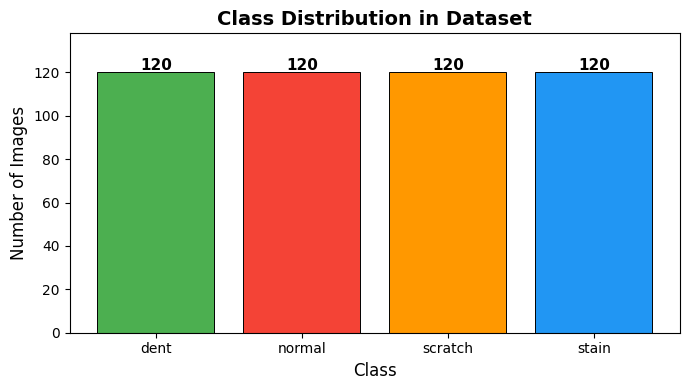


Imbalance ratio (max/min): 1.00
✅ Dataset is well-balanced — no special handling required.


In [5]:
import os
# ------------------------------------------------------------------
# 2.2  Class distribution bar chart
# ------------------------------------------------------------------
colors = ['#4CAF50', '#F44336', '#FF9800', '#2196F3']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.7)
ax.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(class_counts.values) * 1.15)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/class_distribution.png', dpi=150)
plt.show()

# Imbalance check
max_c, min_c = class_counts.max(), class_counts.min()
ratio = max_c / min_c
print(f'\nImbalance ratio (max/min): {ratio:.2f}')
if ratio < 1.5:
    print('✅ Dataset is well-balanced — no special handling required.')
else:
    print('⚠️  Moderate imbalance detected — consider class weights or oversampling.')

In [21]:
# ------------------------------------------------------------------
# 2.3  Image dimensions check
# ------------------------------------------------------------------
sample_sizes = []
for _, row in df.sample(min(40, len(df)), random_state=SEED).iterrows():
    img_path = DATASET_ROOT / row['filename']
    if img_path.exists():
        with Image.open(img_path) as img:
            sample_sizes.append(img.size)   # (width, height)

widths  = [s[0] for s in sample_sizes]
heights = [s[1] for s in sample_sizes]
print('=== Image Dimensions ===')

if sample_sizes:
    print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
    print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')
    unique_sizes = Counter(sample_sizes)
    print(f'Unique WxH combos found: {len(unique_sizes)}')
    print('Most common sizes:', unique_sizes.most_common(3))
else:
    print('⚠️  No image files found. Please ensure the \'images\' directory is uploaded and accessible.')


=== Image Dimensions ===
Width  — min: 96, max: 96, mean: 96
Height — min: 96, max: 96, mean: 96
Unique WxH combos found: 1
Most common sizes: [((96, 96), 40)]


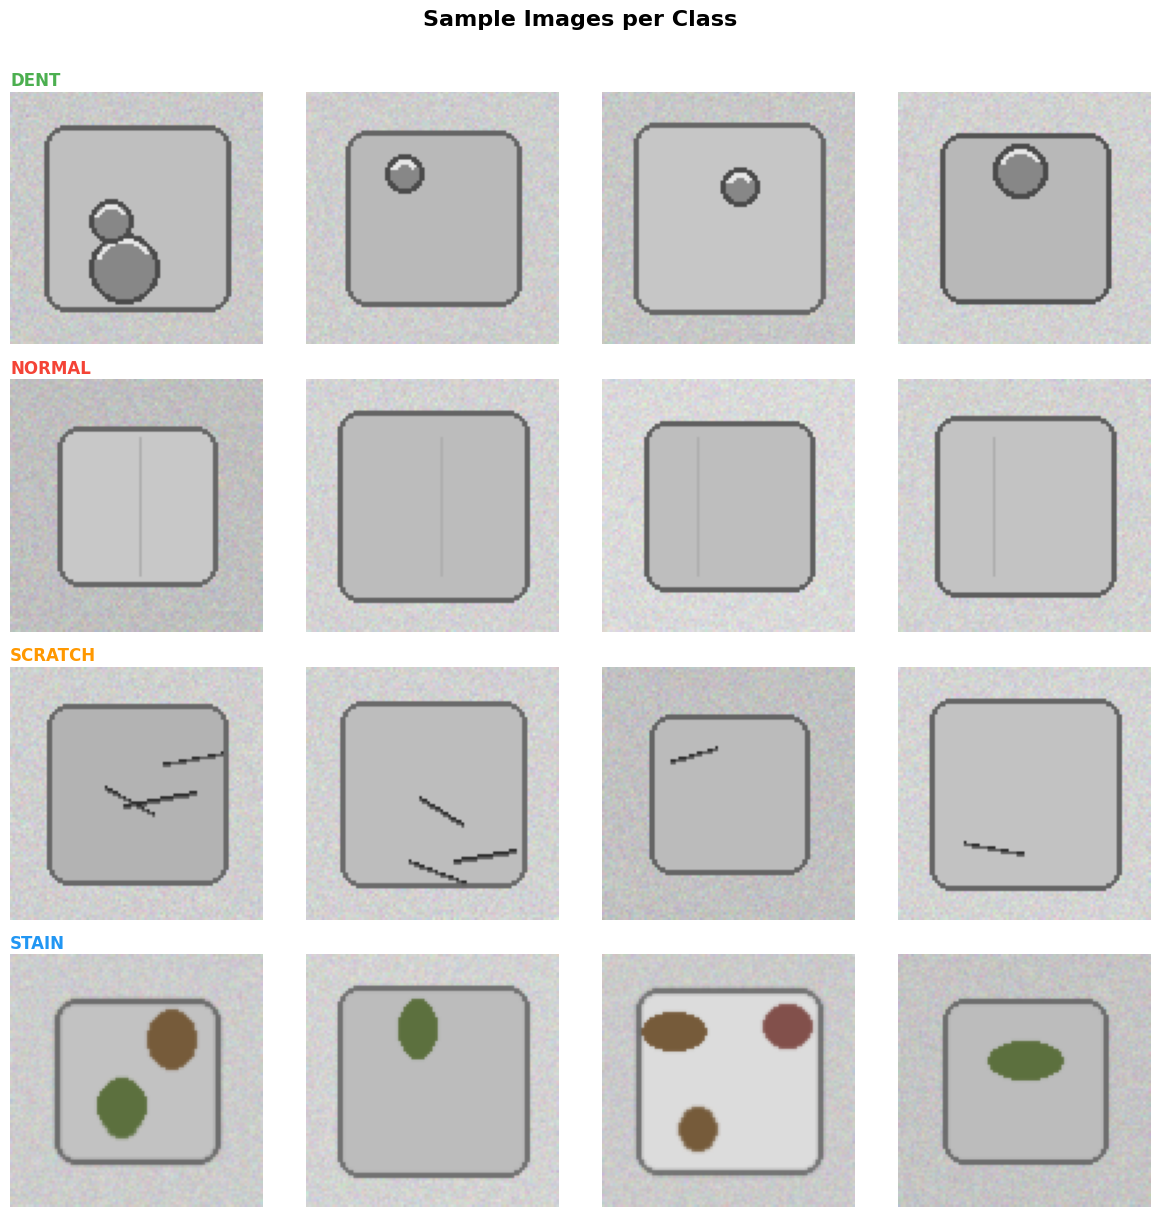

Sample images saved.


In [9]:
# ------------------------------------------------------------------
# 2.4  Sample images from each class
# ------------------------------------------------------------------
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(12, NUM_CLASSES * 3))
fig.suptitle('Sample Images per Class', fontsize=16, fontweight='bold', y=1.01)

for row_idx, cls in enumerate(CLASSES):
    cls_df = df[df['class'] == cls].sample(4, random_state=SEED)
    for col_idx, (_, record) in enumerate(cls_df.iterrows()):
        img_path = DATASET_ROOT / record['filename']
        ax = axes[row_idx][col_idx]
        if img_path.exists():
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
        else:
            ax.set_facecolor('#eee')
            ax.text(0.5, 0.5, 'Image\nnot found', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9)
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(cls.upper(), fontsize=12, fontweight='bold',
                         loc='left', pad=4, color=colors[row_idx])

plt.tight_layout()
plt.savefig('results/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample images saved.')

---
## Task 3: Image Preprocessing

In [10]:
# ------------------------------------------------------------------
# 3.1  Configuration
# ------------------------------------------------------------------
IMG_SIZE   = (128, 128)    # Resize all images to 128×128
BATCH_SIZE = 32
EPOCHS     = 30
VAL_SPLIT  = 0.15          # 15% validation
TEST_SPLIT = 0.15          # 15% test

CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}
print('Class → Index mapping:', CLASS_TO_IDX)

Class → Index mapping: {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


In [11]:
# ------------------------------------------------------------------
# 3.2  Load all images into numpy arrays
# ------------------------------------------------------------------
def load_images(dataframe, root, img_size):
    """Load images and labels; skip missing files."""
    X, y = [], []
    skipped = 0
    for _, row in dataframe.iterrows():
        path = root / row['filename']
        if not path.exists():
            skipped += 1
            continue
        img = Image.open(path).convert('RGB').resize(img_size)
        X.append(np.array(img))
        y.append(CLASS_TO_IDX[row['class']])
    if skipped:
        print(f'⚠️  Skipped {skipped} missing files.')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

print('Loading images...')
X_all, y_all = load_images(df, DATASET_ROOT, IMG_SIZE)

# -------- Normalise pixel values to [0, 1] --------
X_all = X_all / 255.0

print(f'X shape : {X_all.shape}   dtype: {X_all.dtype}')
print(f'y shape : {y_all.shape}   unique classes: {np.unique(y_all)}')
print(f'Pixel range after normalisation: [{X_all.min():.2f}, {X_all.max():.2f}]')

Loading images...
X shape : (480, 128, 128, 3)   dtype: float32
y shape : (480,)   unique classes: [0 1 2 3]
Pixel range after normalisation: [0.09, 1.00]


In [12]:
# ------------------------------------------------------------------
# 3.3  Train / Validation / Test split  (70 / 15 / 15)
# ------------------------------------------------------------------
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SPLIT, stratify=y_all, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    stratify=y_train_val, random_state=SEED)

print('=== Split Summary ===')
print(f'Train      : {X_train.shape[0]} images')
print(f'Validation : {X_val.shape[0]} images')
print(f'Test       : {X_test.shape[0]} images')
print(f'Total      : {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]}')

=== Split Summary ===
Train      : 336 images
Validation : 72 images
Test       : 72 images
Total      : 480


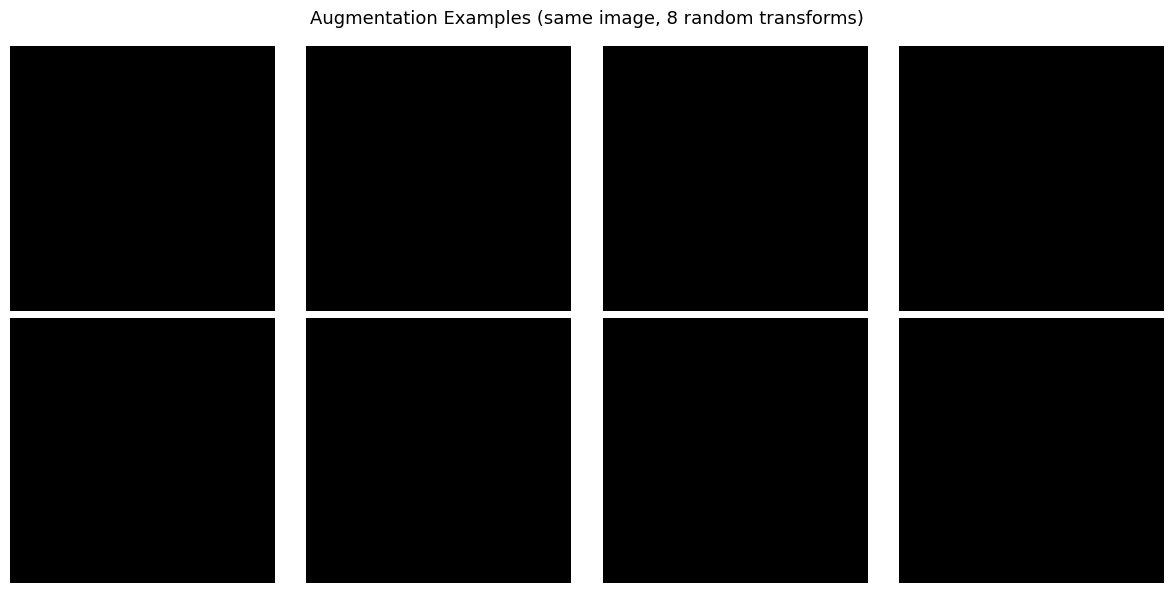

In [13]:
# ------------------------------------------------------------------
# 3.4  Data Augmentation (applied only to training set)
# ------------------------------------------------------------------
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=False,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Visualise one augmentation batch
aug_iter  = datagen.flow(X_train[:1], batch_size=1)
aug_imgs  = [next(aug_iter)[0] for _ in range(8)]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Augmentation Examples (same image, 8 random transforms)', fontsize=13)
for ax, img in zip(axes.flat, aug_imgs):
    ax.imshow(np.clip(img, 0, 1))
    ax.axis('off')
plt.tight_layout()
plt.savefig('results/augmentation_examples.png', dpi=150)
plt.show()

---
## Task 4: CNN Model Creation

In [14]:
# ------------------------------------------------------------------
# 4.1  Build the CNN
# Architecture:
#   Conv(32) → BN → ReLU → MaxPool
#   Conv(64) → BN → ReLU → MaxPool
#   Conv(128)→ BN → ReLU → MaxPool
#   Flatten → Dropout → Dense(256, ReLU) → Dropout → Dense(4, Softmax)
# ------------------------------------------------------------------
def build_cnn(input_shape, num_classes):
    model = models.Sequential(name='Surface_Defect_CNN')

    # --- Block 1: Convolution + Activation + Pooling ---
    model.add(layers.Conv2D(32, (3, 3), padding='same',
                            input_shape=input_shape, name='conv1'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu', name='relu1'))     # Activation function
    model.add(layers.MaxPooling2D((2, 2), name='pool1'))   # Pooling layer

    # --- Block 2 ---
    model.add(layers.Conv2D(64, (3, 3), padding='same', name='conv2'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu', name='relu2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool2'))

    # --- Block 3 ---
    model.add(layers.Conv2D(128, (3, 3), padding='same', name='conv3'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu', name='relu3'))
    model.add(layers.MaxPooling2D((2, 2), name='pool3'))

    # --- Flatten layer ---
    model.add(layers.Flatten(name='flatten'))

    # --- Dense layers ---
    model.add(layers.Dropout(0.4, name='dropout1'))
    model.add(layers.Dense(256, name='dense1'))
    model.add(layers.Activation('relu', name='relu4'))
    model.add(layers.Dropout(0.3, name='dropout2'))

    # --- Output layer (Softmax for multi-class) ---
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model


INPUT_SHAPE = IMG_SIZE + (3,)   # (128, 128, 3)
model = build_cnn(INPUT_SHAPE, NUM_CLASSES)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Surface_Defect_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,036 (32.36 MB)

 Trainable params: 8,483,588 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

---
## Task 5: Model Training and Evaluation

In [15]:
# ------------------------------------------------------------------
# 5.1  Callbacks
# ------------------------------------------------------------------
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        'results/best_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1)
]

In [16]:
# ------------------------------------------------------------------
# 5.2  Train the model
# ------------------------------------------------------------------
train_generator = datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)

history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete!')

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2788 - loss: 1.3863
Epoch 1: val_accuracy improved from None to 0.25000, saving model to results/best_model.keras

Epoch 1: finished saving model to results/best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.2500 - loss: 1.3865 - val_accuracy: 0.2500 - val_loss: 1.3887 - learning_rate: 0.0010
Epoch 2/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.1562 - loss: 1.3867

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.25000
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.1562 - loss: 1.3867 - val_accuracy: 0.2500 - val_loss: 1.3887 - learning_rate: 0.0010
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2289 - loss: 1.3864
Epoch 3: val_accuracy did not improve from 0.25000
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.2171 - loss: 1.3863 - val_accuracy: 0.2500 - val_loss: 1.3892 - learning_rate: 0.0010
Epoch 4/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.2500 - loss: 1.3869
Epoch 4: val_accuracy did not improve from 0.25000
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.2500 - loss: 1.3869 - val_accuracy: 0.2500 - val_loss: 1.3893 - learning_rate: 0.0010
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2620 - loss: 1.3865
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_accuracy did not improve from 0.25000
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accura

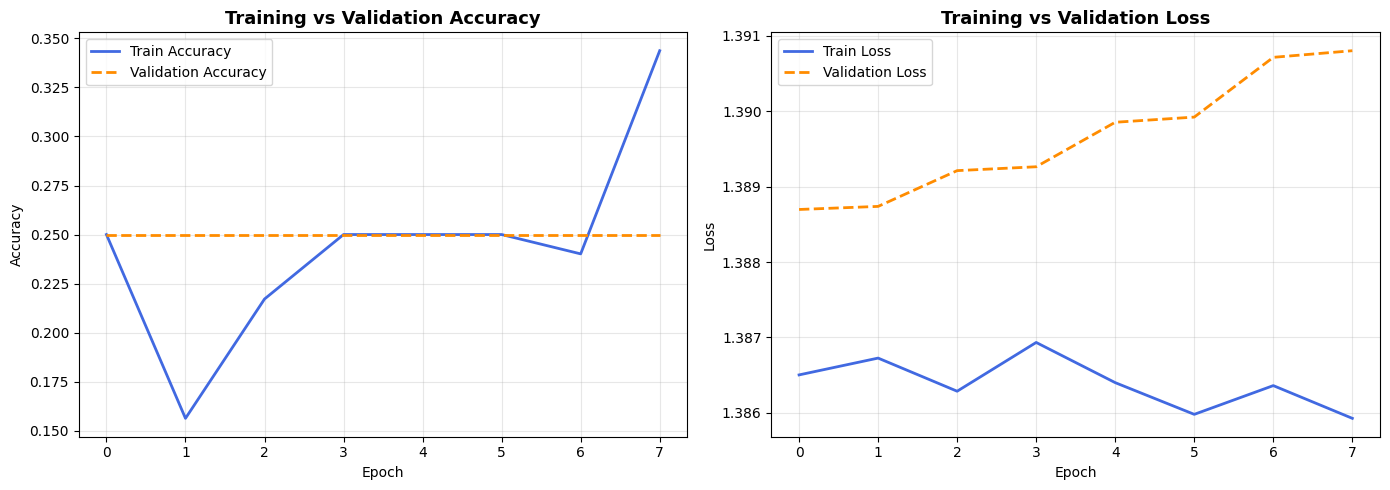

Accuracy/Loss curves saved.


In [17]:
# ------------------------------------------------------------------
# 5.3  Plot training & validation accuracy / loss curves
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
ax = axes[0]
ax.plot(history.history['accuracy'],     label='Train Accuracy',      color='royalblue', linewidth=2)
ax.plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linewidth=2, linestyle='--')
ax.set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3)

# --- Loss ---
ax = axes[1]
ax.plot(history.history['loss'],     label='Train Loss',      color='royalblue', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2, linestyle='--')
ax.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png', dpi=150)
plt.show()
print('Accuracy/Loss curves saved.')

In [18]:
# ------------------------------------------------------------------
# 5.4  Test-set evaluation
# ------------------------------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'=== Test Performance ===')
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc*100:.2f}%')

=== Test Performance ===
Test Loss     : 1.3872
Test Accuracy : 25.00%


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 421ms/step


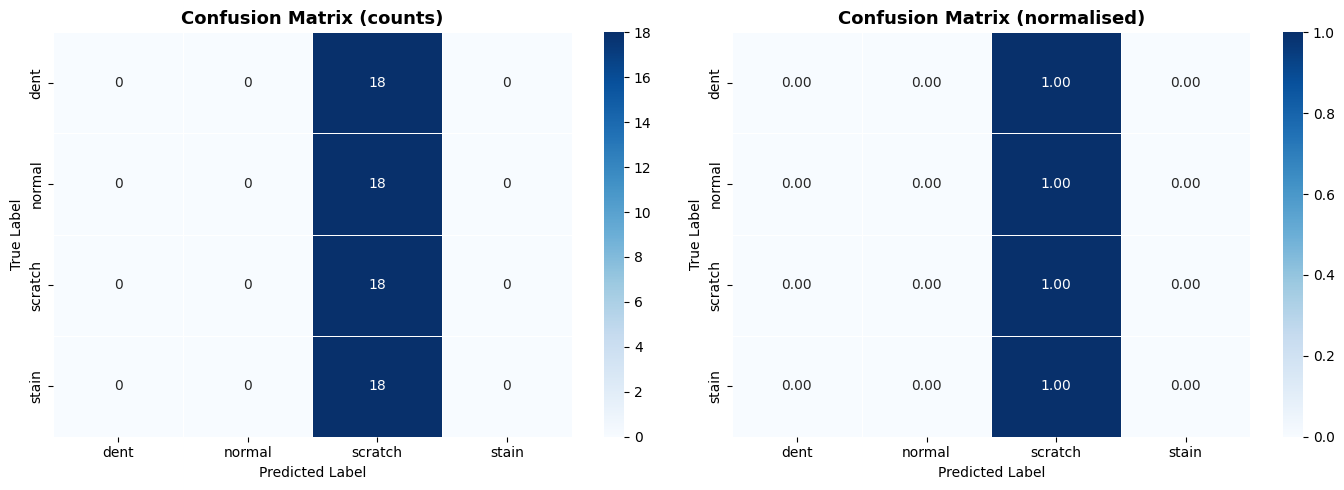


Classification Report:
              precision    recall  f1-score   support

        dent       0.00      0.00      0.00        18
      normal       0.00      0.00      0.00        18
     scratch       0.25      1.00      0.40        18
       stain       0.00      0.00      0.00        18

    accuracy                           0.25        72
   macro avg       0.06      0.25      0.10        72
weighted avg       0.06      0.25      0.10        72



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
# ------------------------------------------------------------------
# 5.5  Confusion Matrix
# ------------------------------------------------------------------
y_pred_probs = model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, fmt in zip(
        axes,
        [cm, cm_norm],
        ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)'],
        ['d', '.2f']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=CLASSES))

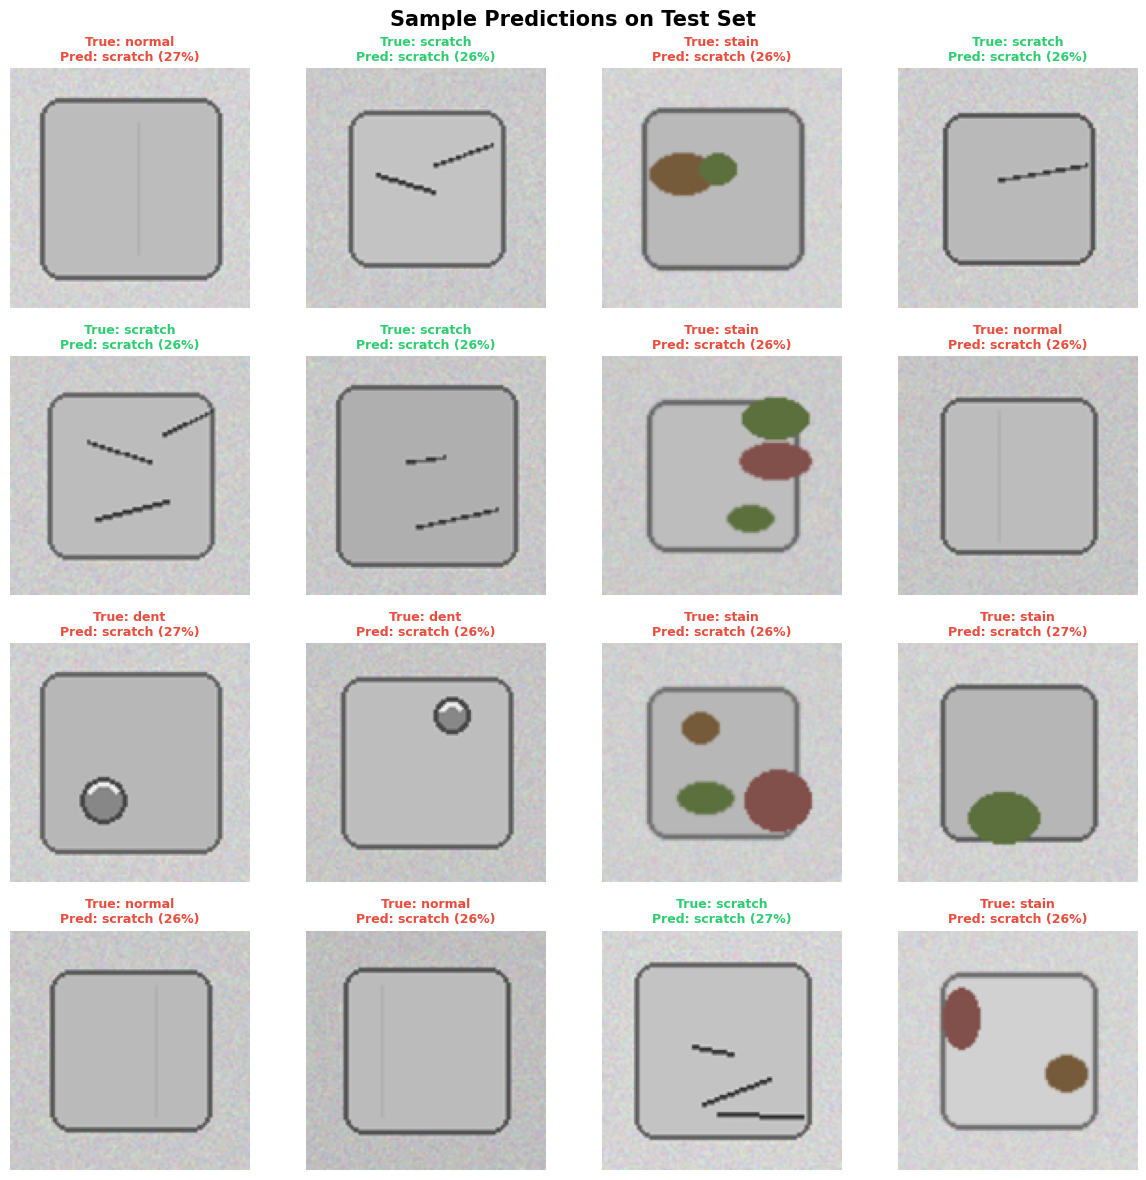

Sample predictions saved.


In [23]:
# ------------------------------------------------------------------
# 5.6  Sample predictions on test images
# ------------------------------------------------------------------
import os

IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
n_show = 16
sample_idx = random.sample(range(len(X_test)), n_show)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Sample Predictions on Test Set', fontsize=15, fontweight='bold')

for ax, idx in zip(axes.flat, sample_idx):
    img   = X_test[idx]
    true  = IDX_TO_CLASS[y_test[idx]]
    pred  = IDX_TO_CLASS[y_pred[idx]]
    conf  = y_pred_probs[idx][y_pred[idx]] * 100
    correct = (true == pred)

    ax.imshow(img)
    ax.axis('off')
    color = '#2ecc71' if correct else '#e74c3c'
    label = f"True: {true}\nPred: {pred} ({conf:.0f}%)"
    ax.set_title(label, fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
os.makedirs('sample_predictions', exist_ok=True)
plt.savefig('sample_predictions/prediction_outputs.png', dpi=150)
plt.show()
print('Sample predictions saved.')

---
## Task 6: CNN Concept Explanation

### What is Convolution?
Convolution is the core mathematical operation in a CNN. A small grid of learnable numbers called a **filter (or kernel)** slides across the input image pixel by pixel. At each position it multiplies the overlapping pixel values by the filter weights and sums the results to produce a single output number. Repeating this across the entire image generates a **feature map** that highlights whichever pattern the filter has learned to detect — e.g. horizontal edges, corners, or textures. Multiple filters in the same layer learn multiple patterns simultaneously.

### Why is Pooling Used?
After convolution, feature maps are often large. **Max-pooling** divides each map into small non-overlapping windows (e.g. 2×2) and keeps only the maximum value from each window. This achieves three things:
1. **Dimensionality reduction** — smaller feature maps mean fewer parameters and faster training.
2. **Translation invariance** — a feature is detected even if it shifts a few pixels.
3. **Noise suppression** — weak activations are discarded.

### Why is ReLU Commonly Used in CNNs?
ReLU (Rectified Linear Unit) sets all negative values to zero: `f(x) = max(0, x)`. It is preferred because:
- It is **computationally trivial** (one comparison per neuron).
- It **avoids the vanishing gradient problem** — unlike sigmoid/tanh, its gradient is 1 for positive values, so deep networks still learn effectively.
- It introduces the **non-linearity** necessary for the network to learn complex decision boundaries.

### Why Are CNNs Better than Regular Feed-Forward Networks for Image Data?
A standard (fully-connected) network treats each pixel as an independent input, discarding all spatial structure. CNNs instead exploit three key properties of images:
1. **Local connectivity** — filters look at small patches, matching how visual patterns (edges, textures) are localised.
2. **Weight sharing** — the same filter is reused across the entire image; millions of parameters in a fully-connected equivalent collapse to a handful of filter weights.
3. **Hierarchical feature learning** — early layers detect edges, middle layers detect shapes, deeper layers detect object parts — naturally matching how humans perceive images.

The result is a model that is more **parameter-efficient**, more **robust to small spatial shifts**, and achieves **far higher accuracy** on image tasks.

---
## Task 7: Business Use Case Mapping

### Domain: Manufacturing — Automated Visual Quality Control

**Scenario:** A steel or automotive parts manufacturer uses a conveyor-belt camera system to photograph every component surface in real time. The trained CNN classifies each surface as *normal*, *scratch*, *stain*, or *dent*.

**Business Impact:**

| Benefit | Detail |
|---------|--------|
| **Cost reduction** | Defective parts are flagged before assembly, preventing expensive recalls or rework. |
| **Throughput** | A CNN can inspect thousands of components per hour — far beyond human capacity. |
| **Consistency** | The model applies the same decision criteria 24/7, eliminating human fatigue and bias. |
| **Traceability** | Prediction logs link each part ID to its defect category for compliance auditing. |
| **Scalability** | One trained model can be deployed across multiple production lines with minimal extra cost. |

**Other applicable domains:**
- **Agriculture** — classify fruit surface quality (bruises, mould, discolouration) at packing stations.
- **Healthcare** — detect skin lesion types from dermoscopy images to assist dermatologists.
- **Retail** — auto-tag product listing photos by condition (new, scratched, stained) on e-commerce platforms.
- **Security** — flag vehicle body damage at toll plazas or car-rental return points.